79. Word Search

Given an m x n grid of characters board and a string word, return true if word exists in the grid.

The word can be constructed from letters of sequentially adjacent cells, where adjacent cells are horizontally or vertically neighboring. The same letter cell may not be used more than once.

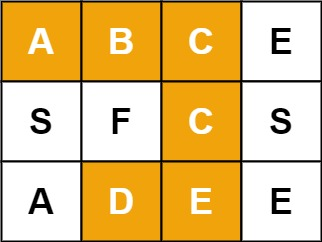

Input: board = [["A","B","C","E"],["S","F","C","S"],["A","D","E","E"]], word = "ABCCED"
Output: true

In [ ]:
from typing import List

class Solution:
    def wordSearch(self, board: List[List[str]], word: str) -> bool:
        rows, columns = len(board), len(board[0])
        
        def dfs(i: int, j: int, index: int) -> bool:
            # 1. Caso base: achou a palavra toda
            if index == len(word):
                return True
            
            # 2. Verificações de limite e letra (CORRIGIDO: word[index] e columns)
            if i < 0 or j < 0 or i >= rows or j >= columns or board[i][j] != word[index]:
                return False

            # 3. BACKTRACKING: "Esconde" a letra para não repetir na mesma busca
            temp = board[i][j]
            board[i][j] = "#"

            # 4. Explora as 4 direções
            found = (dfs(i + 1, j, index + 1) or 
                     dfs(i - 1, j, index + 1) or 
                     dfs(i, j + 1, index + 1) or 
                     dfs(i, j - 1, index + 1))
            
            # 5. RESTAURA a letra original (limpa o rastro)
            board[i][j] = temp
            
            return found

        for i in range(rows):
            for j in range(columns):
                # Se a primeira letra bater, inicia a busca
                if board[i][j] == word[0]:
                    if dfs(i, j, 0):
                        return True
        return False

In [ ]:
from typing import List

class Solution:
    def wordSearch(self, board: List[List[str]], word: str) -> bool:
        rows, cols = len(board), len(board[0])
        for r in range(rows):
            for c in range(cols):
                # Só começamos a busca se a primeira letra bater
                if board[r][c] != word[0]:
                    continue
                    
                # Stack guarda: (linha, coluna, índice_da_letra, rastro_de_visitados)
                # O rastro é uma tupla para ser imutável e simples
                stack = [(r, c, 0, ((r, c),))]
                while stack:
                    curr_r, curr_c, id, visited = stack.pop()
                    # Se o índice chegou no final da palavra, achamos!
                    if id == len(word) - 1:
                        return True
                    # Direções: Baixo, Cima, Direita, Esquerda
                    for dr, dc in [(1, 0), (-1, 0), (0, 1), (0, -1)]:
                        nr, nc = curr_r + dr, curr_c + dc
                        # 1. Verifica limites do tabuleiro
                        # 2. Verifica se a próxima letra coincide
                        # 3. Verifica se a célula NÃO está no rastro atual
                        if (0 <= nr < rows and 0 <= nc < cols and 
                            board[nr][nc] == word[id + 1] and 
                            (nr, nc) not in visited):
                            
                            # Adiciona o novo nó e o novo rastro à pilha
                            stack.append((nr, nc, id + 1, visited + ((nr, nc),)))
                            
        return False

In [3]:
# Test cases for Solution.wordSearch
sol = Solution()

# Test 1: Simple horizontal word
board1 = [
    ['A', 'B', 'C', 'E'],
    ['S', 'F', 'C', 'S'],
    ['A', 'D', 'E', 'E']
]
assert sol.wordSearch(board1, 'ABCCED') == True

# Test 2: Simple vertical word
assert sol.wordSearch(board1, 'SEE') == True

# Test 3: Word not present
assert sol.wordSearch(board1, 'ABCB') == False

# Test 4: Single letter present
assert sol.wordSearch(board1, 'A') == True

# Test 5: Single letter not present
assert sol.wordSearch(board1, 'Z') == False

# Test 6: Word with repeated letters
board2 = [
    ['A', 'A', 'A', 'A'],
    ['A', 'A', 'A', 'A'],
    ['A', 'A', 'A', 'A']
]
assert sol.wordSearch(board2, 'AAAA') == True

print('All test cases passed!')

All test cases passed!
